# GP-KAN with GPytorch

このnotebookでは、GPytorch/linear-operatorライブラリを使用してGP-KANの効率的な実装を行います。

## 目次
1. 環境設定とライブラリのインポート
2. ベンチマーク関数の定義とデータ準備
3. GP-KANアーキテクチャの実装
   - 3.1 GPKANNode: 1次元ガウス過程ノード
   - 3.2 GPKANLayer: エッジベースのレイヤー
   - 3.3 GPKAN: 完全なネットワークモデル
4. モデルの学習と評価
5. 結果の可視化と分析

In [1]:
# ============================================================================
# ハイパーパラメータ設定
# ============================================================================
LR = 0.1              # 学習率
BATCH_SIZE = 256        # バッチサイズ
NUM_EPOCHS = 1000       # エポック数
ARCHITECTURE = [2, 1]   # ネットワーク構造 [入力次元, 出力次元]
NUM_INDUCING = 16       # 誘導点の数

## 1. 環境設定とライブラリのインポート

実験の再現性とライブラリの準備を行います。

In [2]:
# ============================================================================
# 基本ライブラリのインポート
# ============================================================================
import os
import random
import sys
import time
import warnings
from typing import Optional, Tuple

import japanize_matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

# 可視化設定
plt.style.use("default")

# 再現性のための乱数シード設定
def set_seed(seed=42):
    """完全な再現性のための乱数シード設定"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed(42)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.6.0
CUDA available: False


In [3]:
# ============================================================================
# GPytorch関連のインポート
# ============================================================================
import gpytorch
from gpytorch.distributions import MultivariateNormal
from gpytorch.kernels import RBFKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.means import ConstantMean
from gpytorch.mlls import VariationalELBO
from gpytorch.variational import CholeskyVariationalDistribution, VariationalStrategy

print("GPytorch version:", gpytorch.__version__)
print("環境設定完了")

GPytorch version: 1.14
環境設定完了


## 2. ベンチマーク関数の定義とデータ準備

BBOB (Black-Box Optimization Benchmarking) の Sphere 関数を目標関数として使用します。

In [4]:
# ============================================================================
# ベンチマーク関数の定義: Sphere 関数 f₁(x) = ||x - x_opt||² + f_opt
# ============================================================================

# 固定パラメータ
x_opt = np.array([0, 0])  # 最適解位置
f_opt = 10.0               # 最適値

def target_function(x):
    """
    Sphere 関数: f₁(x) = ||x - x_opt||² + f_opt
    
    Args:
        x: 入力ベクトル (N, 2) または (2,)
    Returns:
        関数値 (N,) または スカラー
    """
    x = np.array(x)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    
    # z = x - x_opt
    z = x - x_opt.reshape(1, -1)
    
    # ||z||²の計算
    z_squared_norm = np.sum(z**2, axis=1)
    
    # f₁(x) = ||z||² + f_opt
    result = z_squared_norm + f_opt
    
    return result if len(result) > 1 else result[0]

# 動作確認
print("=== ベンチマーク関数のテスト ===")
print(f"最適解位置: x_opt = {x_opt}")
print(f"最適値: f_opt = {f_opt}")
print(f"f(x_opt) = {target_function(x_opt):.6f} (期待値: {f_opt})")
print(f"f([1, 1]) = {target_function([1, 1]):.6f} (期待値: 2.0)")
print(f"f([2, 0]) = {target_function([2, 0]):.6f} (期待値: 4.0)")

=== ベンチマーク関数のテスト ===
最適解位置: x_opt = [0 0]
最適値: f_opt = 10.0
f(x_opt) = 10.000000 (期待値: 10.0)
f([1, 1]) = 12.000000 (期待値: 2.0)
f([2, 0]) = 14.000000 (期待値: 4.0)


In [5]:
# ============================================================================
# データセットの作成とDataLoaderの準備
# ============================================================================

num_samples = 1000
input_range = [-2, 2]  # 入力範囲

# 2次元入力点をランダムサンプリング
X = np.random.uniform(input_range[0], input_range[1], (num_samples, 2))
y = target_function(X)

# PyTorchテンソルに変換
X_tensor = torch.FloatTensor(X)
y_tensor = torch.FloatTensor(y).reshape(-1, 1)

# データ分割（学習:検証:テスト = 7:1.5:1.5）
train_size = int(0.7 * num_samples)
val_size = int(0.15 * num_samples)

X_train = X_tensor[:train_size]
y_train = y_tensor[:train_size]
X_val = X_tensor[train_size:train_size + val_size]
y_val = y_tensor[train_size:train_size + val_size]
X_test = X_tensor[train_size + val_size:]
y_test = y_tensor[train_size + val_size:]

# データセットとDataLoader作成
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

def worker_init_fn(worker_id):
    """DataLoaderワーカープロセス用の乱数シード設定"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

generator = torch.Generator().manual_seed(42)

train_dataloader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, worker_init_fn=worker_init_fn, generator=generator
)
val_dataloader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, worker_init_fn=worker_init_fn, generator=generator
)
test_dataloader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, worker_init_fn=worker_init_fn, generator=generator
)

print(f"=== データセット作成完了 ===")
print(f"学習データ: {len(train_dataset)} samples")
print(f"検証データ: {len(val_dataset)} samples")
print(f"テストデータ: {len(test_dataset)} samples")
print(f"入力次元: {X_train.shape[1]}")
print(f"関数値範囲: [{y.min():.3f}, {y.max():.3f}]")

=== データセット作成完了 ===
学習データ: 700 samples
検証データ: 150 samples
テストデータ: 150 samples
入力次元: 2
関数値範囲: [10.002, 17.383]


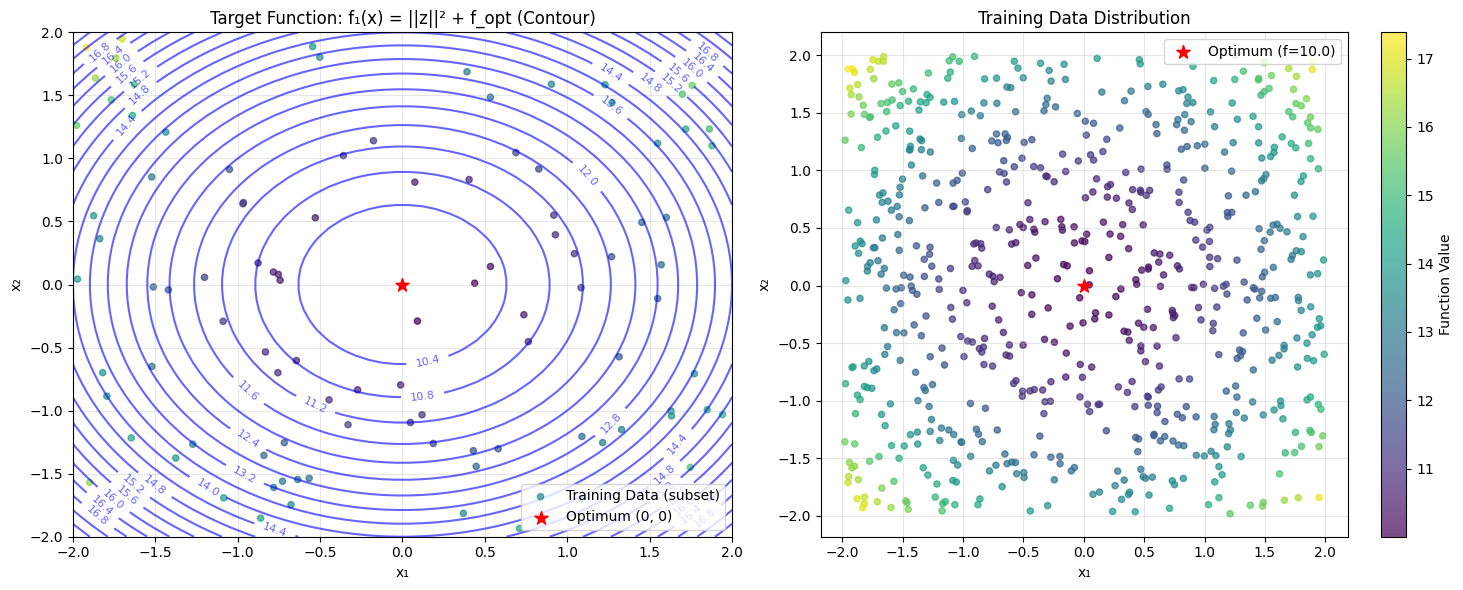

最適解での関数値: f(x_opt) = 10.000000
データの統計:
  平均: 12.731
  標準偏差: 1.744
  最小値: 10.002
  最大値: 17.383


In [6]:
# 関数の可視化
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 3D表面プロット用のグリッド作成
x1_grid = np.linspace(input_range[0], input_range[1], 50)
x2_grid = np.linspace(input_range[0], input_range[1], 50)
X1_grid, X2_grid = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
Z_grid = target_function(grid_points).reshape(X1_grid.shape)

# 左: 等高線プロット
contour = axes[0].contour(X1_grid, X2_grid, Z_grid, levels=20, colors="blue", alpha=0.6)
axes[0].clabel(contour, inline=True, fontsize=8)
axes[0].scatter(
    X_train[:100, 0],
    X_train[:100, 1],
    c=y_train[:100],
    cmap="viridis",
    s=20,
    alpha=0.7,
    label="Training Data (subset)",
)
axes[0].scatter(
    x_opt[0],
    x_opt[1],
    c="red",
    s=100,
    marker="*",
    label=f"Optimum ({x_opt[0]}, {x_opt[1]})",
    zorder=5,
)
axes[0].set_xlabel("x₁")
axes[0].set_ylabel("x₂")
axes[0].set_title("Target Function: f₁(x) = ||z||² + f_opt (Contour)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右: 散布図（関数値の分布）
scatter = axes[1].scatter(
    X_train[:, 0], X_train[:, 1], c=y_train.numpy(), cmap="viridis", s=20, alpha=0.7
)
axes[1].scatter(
    x_opt[0],
    x_opt[1],
    c="red",
    s=100,
    marker="*",
    label=f"Optimum (f={f_opt})",
    zorder=5,
)
plt.colorbar(scatter, ax=axes[1], label="Function Value")
axes[1].set_xlabel("x₁")
axes[1].set_ylabel("x₂")
axes[1].set_title("Training Data Distribution")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"最適解での関数値: f(x_opt) = {target_function(x_opt):.6f}")
print(f"データの統計:")
print(f"  平均: {y.mean():.3f}")
print(f"  標準偏差: {y.std():.3f}")
print(f"  最小値: {y.min():.3f}")
print(f"  最大値: {y.max():.3f}")

## 3. GP-KANアーキテクチャの実装

GP-KAN (Gaussian Process Kolmogorov-Arnold Network) は以下の2つの制約を満たします：

**制約1**: 各ノードで1次元ガウス過程による非線形変換を行う  
**制約2**: 各エッジでは総和を計算（学習パラメータなし）

### 3.1 GPKANNode: 1次元ガウス過程ノード

各ノードは変分推論を使った1次元GPで実装されます。

In [7]:
# ============================================================================
# GPKANNode: 1次元ガウス過程ノードの実装
# ============================================================================

class GPKANNode(gpytorch.models.ApproximateGP):
    """
    GP-KANの基本構成要素：1次元ガウス過程ノード
    
    変分推論を使用して学習可能な1次元ガウス過程を実装。
    各ノードは以下を持つ：
    - 誘導点 (inducing points): スパース近似のための代表点
    - RBFカーネル: 入力間の類似度を測る関数
    - 変分分布: 真の事後分布の近似
    """
    
    def __init__(self, inducing_points: torch.Tensor):
        """
        Args:
            inducing_points: 誘導点の初期位置 (shape: [num_inducing, 1])
        """
        # 変分分布の設定（Cholesky分解を使った多変量正規分布）
        variational_distribution = CholeskyVariationalDistribution(
            inducing_points.size(0)
        )
        
        # 変分戦略の設定（誘導点の位置も学習可能）
        variational_strategy = VariationalStrategy(
            self,
            inducing_points,
            variational_distribution,
            learn_inducing_locations=True
        )
        
        super(GPKANNode, self).__init__(variational_strategy)
        
        # 平均関数: 定数（学習可能）
        self.mean_module = ConstantMean()
        
        # 共分散関数: スケール付きRBFカーネル
        self.covar_module = ScaleKernel(RBFKernel())
    
    def forward(self, x: torch.Tensor) -> MultivariateNormal:
        """
        順伝播: 入力に対するGP分布を返す
        
        Args:
            x: 入力テンソル (shape: [batch_size, 1])
        Returns:
            多変量正規分布（平均と共分散を持つGP分布）
        """
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return MultivariateNormal(mean_x, covar_x)
    
    def get_inducing_points(self) -> torch.Tensor:
        """誘導点の現在位置を取得"""
        return self.variational_strategy.inducing_points

print("GPKANNode クラス定義完了")

GPKANNode クラス定義完了


### 3.2 GPKANLayer: エッジベースのレイヤー

GPKANレイヤーは以下の処理を行います：
1. 各入力次元 i と各出力次元 j に対してGPエッジ (i→j) を作成
2. 各入力次元を独立に1次元GPで変換
3. 出力ノードで全エッジからの寄与を総和（制約2）

In [8]:
# ============================================================================
# GPKANLayer: エッジベースのレイヤー実装（修正版）
# ============================================================================

class GPKANLayer(nn.Module):
    """
    GP-KANレイヤー: エッジベースの処理を実装（修正版）
    """
    
    def __init__(
        self,
        input_size: int,
        output_size: int,
        num_inducing: int = 10,
        inducing_range: tuple = (-2.0, 2.0)
    ):
        super(GPKANLayer, self).__init__()
        
        self.input_size = input_size
        self.output_size = output_size
        self.num_inducing = num_inducing
        
        # GPエッジとlikelihoodの作成
        self.gp_edges = nn.ModuleList()
        self.likelihoods = nn.ModuleList()
        
        for i in range(input_size):
            row_edges = nn.ModuleList()
            row_likelihoods = nn.ModuleList()
            
            for j in range(output_size):
                inducing_points = torch.linspace(
                    inducing_range[0], inducing_range[1], num_inducing
                ).reshape(-1, 1)
                
                gp_edge = GPKANNode(inducing_points)
                likelihood = GaussianLikelihood()
                
                row_edges.append(gp_edge)
                row_likelihoods.append(likelihood)
            
            self.gp_edges.append(row_edges)
            self.likelihoods.append(row_likelihoods)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """順伝播: エッジベースの処理"""
        batch_size = x.size(0)
        outputs = []
        
        for j in range(self.output_size):
            node_output = 0.0
            
            for i in range(self.input_size):
                gp_edge = self.gp_edges[i][j]
                input_i = x[:, i:i+1]
                gp_output = gp_edge(input_i)
                samples = gp_output.rsample()
                node_output = node_output + samples
            
            outputs.append(node_output.unsqueeze(-1))
        
        output = torch.cat(outputs, dim=-1)
        return output
    
    def get_loss(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        修正版: 合計出力に対する損失を計算
        
        ★変更点: 各エッジが独立にyを予測するのではなく、
                 全エッジの合計出力がyに一致するように学習
        """
        batch_size = x.size(0)
        
        # 各出力次元について処理
        total_loss = 0.0
        
        for j in range(self.output_size):
            # このノードへの全エッジの寄与を収集
            edge_contributions = []
            
            for i in range(self.input_size):
                gp_edge = self.gp_edges[i][j]
                likelihood = self.likelihoods[i][j]
                
                input_i = x[:, i:i+1]
                gp_output = gp_edge(input_i)
                
                edge_contributions.append(gp_output)
            
            # ★修正: 全エッジの合計分布を計算
            # 各エッジの平均と分散を合計
            combined_mean = sum(gp.mean for gp in edge_contributions)
            combined_var = sum(gp.variance for gp in edge_contributions)
            
            # 合計分布を作成
            from torch.distributions import Normal
            combined_dist = Normal(combined_mean, torch.sqrt(combined_var))
            
            # ターゲット
            if self.output_size == 1:
                target = y.squeeze(-1)
            else:
                target = y[:, j]
            
            # 合計出力に対する負の対数尤度
            loss = -combined_dist.log_prob(target).mean()
            
            # KL損失の追加（各エッジの変分推論項）
            for i in range(self.input_size):
                gp_edge = self.gp_edges[i][j]
                # 変分分布と事前分布のKLダイバージェンス
                kl_divergence = gp_edge.variational_strategy.kl_divergence().sum()
                loss = loss + kl_divergence / (batch_size * self.input_size)
            
            total_loss += loss
        
        return total_loss
    
    def train_mode(self):
        """全GPノードとlikelihoodを学習モードに"""
        self.train()
        for i in range(self.input_size):
            for j in range(self.output_size):
                self.gp_edges[i][j].train()
                self.likelihoods[i][j].train()
    
    def eval_mode(self):
        """全GPノードとlikelihoodを評価モードに"""
        self.eval()
        for i in range(self.input_size):
            for j in range(self.output_size):
                self.gp_edges[i][j].eval()
                self.likelihoods[i][j].eval()

print("GPKANLayer クラス定義完了（修正版: 合計出力損失）")

GPKANLayer クラス定義完了（修正版: 合計出力損失）


### 3.3 GPKAN: 完全なネットワークモデル

複数のGPKANLayerを積み重ねて深層ネットワークを構築します。

## 補足: GP-KAN損失関数の数学的定義

GP-KANの損失関数は、**変分推論（Variational Inference）**に基づいて設計されています。

### 1. モデルの構造

GP-KANは以下のように動作します：

**入力から出力への変換**:
$$
\text{出力ノード } j: \quad y_j = \sum_{i=1}^{d_{\text{in}}} f_{ij}(x_i)
$$

ここで：
- $x_i$: 入力の第$i$次元
- $f_{ij}(\cdot)$: エッジ$(i \to j)$のガウス過程
- $y_j$: 出力の第$j$次元

### 2. ガウス過程の予測分布

各GPエッジ$f_{ij}$は、入力$x_i$に対して以下の予測分布を出力します：

$$
f_{ij}(x_i) \sim \mathcal{N}(\mu_{ij}(x_i), \sigma^2_{ij}(x_i))
$$

**全エッジの合計分布**（独立性の仮定）:
$$
\sum_{i=1}^{d_{\text{in}}} f_{ij}(x_i) \sim \mathcal{N}\left(\sum_{i=1}^{d_{\text{in}}} \mu_{ij}(x_i), \sum_{i=1}^{d_{\text{in}}} \sigma^2_{ij}(x_i)\right)
$$

これを$\mathcal{N}(\mu_{\text{total}}, \sigma^2_{\text{total}})$と表記します。

### 3. 損失関数の定義

GP-KANの損失関数は、**負の対数尤度（Negative Log-Likelihood, NLL）**と**KLダイバージェンス**の和で構成されます：

$$
\mathcal{L} = \underbrace{-\log p(y \mid \mu_{\text{total}}, \sigma^2_{\text{total}})}_{\text{データ適合項（NLL）}} + \underbrace{\beta \sum_{i,j} \text{KL}(q(f_{ij}) \| p(f_{ij}))}_{\text{正則化項（KL損失）}}
$$

#### 3.1 データ適合項（Negative Log-Likelihood）

目標値$y$が正規分布$\mathcal{N}(\mu_{\text{total}}, \sigma^2_{\text{total}})$から生成されると仮定した場合の対数尤度：

$$
\log p(y \mid \mu_{\text{total}}, \sigma^2_{\text{total}}) = -\frac{1}{2}\log(2\pi\sigma^2_{\text{total}}) - \frac{(y - \mu_{\text{total}})^2}{2\sigma^2_{\text{total}}}
$$

バッチ平均を取ると：

$$
\text{NLL} = -\frac{1}{N}\sum_{n=1}^{N} \log p(y^{(n)} \mid \mu^{(n)}_{\text{total}}, (\sigma^2_{\text{total}})^{(n)})
$$

#### 3.2 正則化項（KL損失）

各GPエッジの変分分布$q(f_{ij})$と事前分布$p(f_{ij})$のKLダイバージェンス：

$$
\text{KL}(q(f_{ij}) \| p(f_{ij})) = \int q(f_{ij}) \log \frac{q(f_{ij})}{p(f_{ij})} df_{ij}
$$

これは**変分推論の正則化項**として機能し、GPが事前分布から大きく逸脱することを防ぎます。

総KL損失（全エッジの合計）:

$$
\text{KL}_{\text{total}} = \sum_{i=1}^{d_{\text{in}}} \sum_{j=1}^{d_{\text{out}}} \text{KL}(q(f_{ij}) \| p(f_{ij}))
$$

**スケーリング係数**:
$$
\beta = \frac{1}{N \cdot d_{\text{in}}}
$$

ここで、$N$はバッチサイズ、$d_{\text{in}}$は入力次元数です。

### 4. 最終的な損失関数

出力次元$j$に対する損失：

$$
\mathcal{L}_j = -\frac{1}{N}\sum_{n=1}^{N} \log \mathcal{N}\left(y^{(n)}_j \mid \mu^{(n)}_{\text{total}}, (\sigma^2_{\text{total}})^{(n)}\right) + \frac{1}{N \cdot d_{\text{in}}} \sum_{i=1}^{d_{\text{in}}} \text{KL}(q(f_{ij}) \| p(f_{ij}))
$$

全出力次元の損失を合計：

$$
\mathcal{L} = \sum_{j=1}^{d_{\text{out}}} \mathcal{L}_j
$$

### 5. 実装との対応

```python
# GPKANLayer.get_loss() の処理フロー

for j in range(output_size):
    # 1. 全エッジの寄与を収集
    edge_contributions = [gp_edges[i][j](x[:, i]) for i in range(input_size)]
    
    # 2. 合計分布の計算
    combined_mean = sum(gp.mean for gp in edge_contributions)
    combined_var = sum(gp.variance for gp in edge_contributions)
    
    # 3. データ適合項（NLL）
    combined_dist = Normal(combined_mean, sqrt(combined_var))
    nll_loss = -combined_dist.log_prob(y).mean()
    
    # 4. KL損失（正則化項）
    kl_loss = sum(gp_edges[i][j].kl_divergence() for i in range(input_size))
    kl_loss = kl_loss / (batch_size * input_size)
    
    # 5. 合計
    loss_j = nll_loss + kl_loss
    total_loss += loss_j
```

### 6. 重要なポイント

1. **エッジの協調学習**: 各エッジが「目標値の一部」を担当するように学習
2. **不確実性の伝播**: 分散の加法性により、複数のGPの不確実性が適切に統合される
3. **過学習の防止**: KL損失がGPを事前分布に近づける正則化として機能
4. **スケーリング**: KL損失を$\beta = \frac{1}{N \cdot d_{\text{in}}}$でスケーリングし、データ適合項とバランス

この設計により、GP-KANは**確率的な予測**と**効率的な学習**を両立します。

In [9]:
# ============================================================================
# GPKAN: 完全なネットワークモデル
# ============================================================================

# ============================================================================
# GPKAN: 完全なネットワークモデル（修正版2）
# ============================================================================

class GPKAN(nn.Module):
    """
    GP-KAN (Gaussian Process Kolmogorov-Arnold Network)（完全修正版）
    """
    
    def __init__(
        self,
        layer_sizes: list,
        num_inducing: int = 10,
        inducing_range: Tuple[float, float] = (-2.0, 2.0)
    ):
        super(GPKAN, self).__init__()
        
        self.layer_sizes = layer_sizes
        self.num_layers = len(layer_sizes) - 1
        self.num_inducing = num_inducing
        
        self.layers = nn.ModuleList()
        for i in range(self.num_layers):
            layer = GPKANLayer(
                input_size=layer_sizes[i],
                output_size=layer_sizes[i + 1],
                num_inducing=num_inducing,
                inducing_range=inducing_range
            )
            self.layers.append(layer)
        
        self.likelihood = GaussianLikelihood()
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """順伝播"""
        current_input = x
        for layer in self.layers:
            current_input = layer(current_input)
        return current_input
    
    def predict(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        予測を実行（完全修正版：全エッジを使用）
        """
        self.eval()
        with torch.no_grad():
            # 最終層まで順伝播
            current_input = x
            for layer in self.layers[:-1]:
                current_input = layer(current_input)
            
            # 最終層の処理（全エッジからの寄与を集約）
            final_layer = self.layers[-1]
            batch_size = current_input.size(0)
            
            # 各出力次元について予測
            predictions = []
            variances = []
            
            for j in range(final_layer.output_size):
                node_mean = torch.zeros(batch_size)
                node_var = torch.zeros(batch_size)
                
                # 全入力次元からの寄与を集約
                for i in range(final_layer.input_size):
                    gp_edge = final_layer.gp_edges[i][j]
                    likelihood = final_layer.likelihoods[i][j]
                    
                    input_i = current_input[:, i:i+1]
                    gp_dist = gp_edge(input_i)
                    pred_dist = likelihood(gp_dist)
                    
                    node_mean = node_mean + pred_dist.mean
                    node_var = node_var + pred_dist.variance
                
                predictions.append(node_mean)
                variances.append(node_var)
            
            if final_layer.output_size == 1:
                return predictions[0], variances[0]
            else:
                return torch.stack(predictions, dim=-1), torch.stack(variances, dim=-1)
    
    def get_total_loss(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        全レイヤーの損失を計算（完全修正版）
        
        ★修正ポイント: 最終層でも layer.get_loss() を使用
        """
        current_input = x
        total_loss = 0.0
        
        for i, layer in enumerate(self.layers):
            if i == len(self.layers) - 1:
                # ★最終層: 全エッジの損失を layer.get_loss() で計算
                loss = layer.get_loss(current_input, y)
                total_loss += loss
            else:
                # 中間層: 次の層への伝播
                current_input = layer(current_input)
        
        return total_loss
    
    def train_mode(self):
        """全レイヤーを学習モードに設定"""
        self.train()
        self.likelihood.train()
        for layer in self.layers:
            layer.train_mode()
    
    def eval_mode(self):
        """全レイヤーを評価モードに設定"""
        self.eval()
        self.likelihood.eval()
        for layer in self.layers:
            layer.eval_mode()
    
    def print_model_info(self):
        """モデル構造の詳細を表示"""
        total_gps = sum(
            layer.input_size * layer.output_size for layer in self.layers
        )
        total_inducing = total_gps * self.num_inducing
        
        print("=" * 60)
        print("GP-KAN Model Architecture")
        print("=" * 60)
        print(f"Layer structure: {self.layer_sizes}")
        print(f"Number of layers: {self.num_layers}")
        print(f"Total GP edges: {total_gps}")
        print(f"Inducing points per GP: {self.num_inducing}")
        print(f"Total inducing points: {total_inducing}")
        print(f"Likelihood: {self.likelihood}")
        print("-" * 60)
        
        for i, layer in enumerate(self.layers):
            num_edges = layer.input_size * layer.output_size
            print(f"Layer {i+1}: {layer.input_size}→{layer.output_size} " +
                  f"({num_edges} GP edges)")
        print("=" * 60)

print("GPKAN クラス定義完了（完全修正版）")

# モデルの作成
print("\n=== GP-KANモデルを作成中 ===")
gpkan_model = GPKAN(
    layer_sizes=ARCHITECTURE,
    num_inducing=NUM_INDUCING,
    inducing_range=(-1.5, 1.5)
)

gpkan_model.print_model_info()

# パラメータ数の表示
total_params = sum(p.numel() for p in gpkan_model.parameters())
trainable_params = sum(
    p.numel() for p in gpkan_model.parameters() if p.requires_grad
)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

GPKAN クラス定義完了（完全修正版）

=== GP-KANモデルを作成中 ===
GP-KAN Model Architecture
Layer structure: [2, 1]
Number of layers: 1
Total GP edges: 2
Inducing points per GP: 16
Total inducing points: 32
Likelihood: GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-04)
  )
)
------------------------------------------------------------
Layer 1: 2→1 (2 GP edges)

Total parameters: 585
Trainable parameters: 585
GP-KAN Model Architecture
Layer structure: [2, 1]
Number of layers: 1
Total GP edges: 2
Inducing points per GP: 16
Total inducing points: 32
Likelihood: GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-04)
  )
)
------------------------------------------------------------
Layer 1: 2→1 (2 GP edges)

Total parameters: 585
Trainable parameters: 585


## 4. モデルの学習と評価

GP-KANモデルを学習し、性能を評価します。

In [10]:
# ============================================================================
# 学習ループの実装
# ============================================================================

def train_gpkan(
    model: GPKAN,
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_epochs: int,
    learning_rate: float
) -> Tuple[list, list]:
    """
    GP-KANモデルの学習
    
    Args:
        model: GP-KANモデル
        train_loader: 訓練データローダー
        val_loader: 検証データローダー
        num_epochs: エポック数
        learning_rate: 学習率
    
    Returns:
        (train_losses, val_losses) 学習・検証損失のリスト
    """
    model.train_mode()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=learning_rate * 0.01
    )
    
    train_losses = []
    val_losses = []
    
    start_time = time.time()
    
    for epoch in range(num_epochs):
        # === 訓練フェーズ ===
        model.train_mode()
        epoch_train_loss = 0.0
        num_batches = 0
        
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            loss = model.get_total_loss(batch_x, batch_y)
            loss.backward()
            optimizer.step()
            
            epoch_train_loss += loss.item()
            num_batches += 1
        
        avg_train_loss = epoch_train_loss / num_batches
        train_losses.append(avg_train_loss)
        
        # === 検証フェーズ ===
        model.eval_mode()
        val_loss = 0.0
        val_batches = 0
        
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                loss = model.get_total_loss(batch_x, batch_y)
                val_loss += loss.item()
                val_batches += 1
        
        avg_val_loss = val_loss / val_batches
        val_losses.append(avg_val_loss)
        
        # 学習率調整
        scheduler.step()
        
        # 進捗表示
        if (epoch + 1) % 25 == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f"Epoch {epoch+1}/{num_epochs} | " +
                  f"Train Loss: {avg_train_loss:.4f} | " +
                  f"Val Loss: {avg_val_loss:.4f} | " +
                  f"LR: {current_lr:.6f}")
    
    training_time = time.time() - start_time
    print(f"\n学習完了! 所要時間: {training_time:.2f}秒")
    print(f"最終 Train Loss: {train_losses[-1]:.4f}")
    print(f"最終 Val Loss: {val_losses[-1]:.4f}")
    
    return train_losses, val_losses

# 学習実行
print("=== GP-KANモデルの学習を開始 ===\n")
train_losses, val_losses = train_gpkan(
    model=gpkan_model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    num_epochs=NUM_EPOCHS,
    learning_rate=LR
)

=== GP-KANモデルの学習を開始 ===

Epoch 25/1000 | Train Loss: 2.9140 | Val Loss: 3.0208 | LR: 0.099847
Epoch 25/1000 | Train Loss: 2.9140 | Val Loss: 3.0208 | LR: 0.099847
Epoch 50/1000 | Train Loss: 1.8689 | Val Loss: 1.9315 | LR: 0.099391
Epoch 50/1000 | Train Loss: 1.8689 | Val Loss: 1.9315 | LR: 0.099391
Epoch 75/1000 | Train Loss: 0.4367 | Val Loss: 0.7319 | LR: 0.098632
Epoch 75/1000 | Train Loss: 0.4367 | Val Loss: 0.7319 | LR: 0.098632
Epoch 100/1000 | Train Loss: 0.8931 | Val Loss: 0.8708 | LR: 0.097577
Epoch 100/1000 | Train Loss: 0.8931 | Val Loss: 0.8708 | LR: 0.097577
Epoch 125/1000 | Train Loss: 0.0808 | Val Loss: 0.2108 | LR: 0.096232
Epoch 125/1000 | Train Loss: 0.0808 | Val Loss: 0.2108 | LR: 0.096232
Epoch 150/1000 | Train Loss: 0.0393 | Val Loss: 0.1182 | LR: 0.094605
Epoch 150/1000 | Train Loss: 0.0393 | Val Loss: 0.1182 | LR: 0.094605
Epoch 175/1000 | Train Loss: 0.7899 | Val Loss: 0.7826 | LR: 0.092706
Epoch 175/1000 | Train Loss: 0.7899 | Val Loss: 0.7826 | LR: 0.092706
E

### 4.1 テストデータでのモデル評価

In [11]:
# ============================================================================
# テストデータでの評価
# ============================================================================

gpkan_model.eval_mode()

# テストデータでの予測（バッチ処理）
test_means = []
test_vars = []

with torch.no_grad():
    for batch_x, batch_y in test_dataloader:
        test_mean, test_var = gpkan_model.predict(batch_x)
        test_means.append(test_mean)
        test_vars.append(test_var)

test_mean = torch.cat(test_means, dim=0)
test_var = torch.cat(test_vars, dim=0)

# 評価指標の計算
test_rmse = torch.sqrt(torch.mean((test_mean - y_test.squeeze()) ** 2))
test_mae = torch.mean(torch.abs(test_mean - y_test.squeeze()))
test_r2 = 1 - torch.sum((y_test.squeeze() - test_mean) ** 2) / \
          torch.sum((y_test.squeeze() - y_test.mean()) ** 2)

print("=" * 60)
print("GP-KAN テスト性能評価")
print("=" * 60)
print(f"RMSE (Root Mean Squared Error): {test_rmse.item():.6f}")
print(f"MAE (Mean Absolute Error):      {test_mae.item():.6f}")
print(f"R² Score:                       {test_r2.item():.6f}")
print(f"平均予測分散:                    {test_var.mean().item():.6f}")
print("=" * 60)

GP-KAN テスト性能評価
RMSE (Root Mean Squared Error): 0.029868
MAE (Mean Absolute Error):      0.015332
R² Score:                       0.999713
平均予測分散:                    1.387187


## 5. 結果の可視化と分析

学習曲線、予測精度、GP活性化関数などを可視化します。

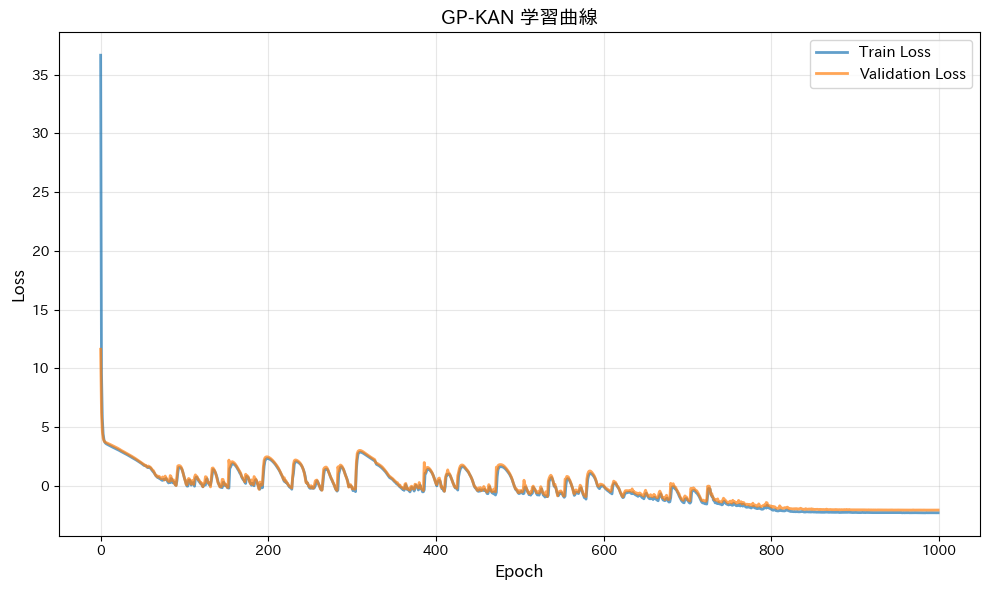

最終 Train Loss: -2.3222
最終 Validation Loss: -2.0908


In [12]:
japanize_matplotlib.japanize()
# ============================================================================
# 学習曲線の可視化
# ============================================================================

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', alpha=0.7, linewidth=2)
plt.plot(val_losses, label='Validation Loss', alpha=0.7, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('GP-KAN 学習曲線', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"最終 Train Loss: {train_losses[-1]:.4f}")
print(f"最終 Validation Loss: {val_losses[-1]:.4f}")


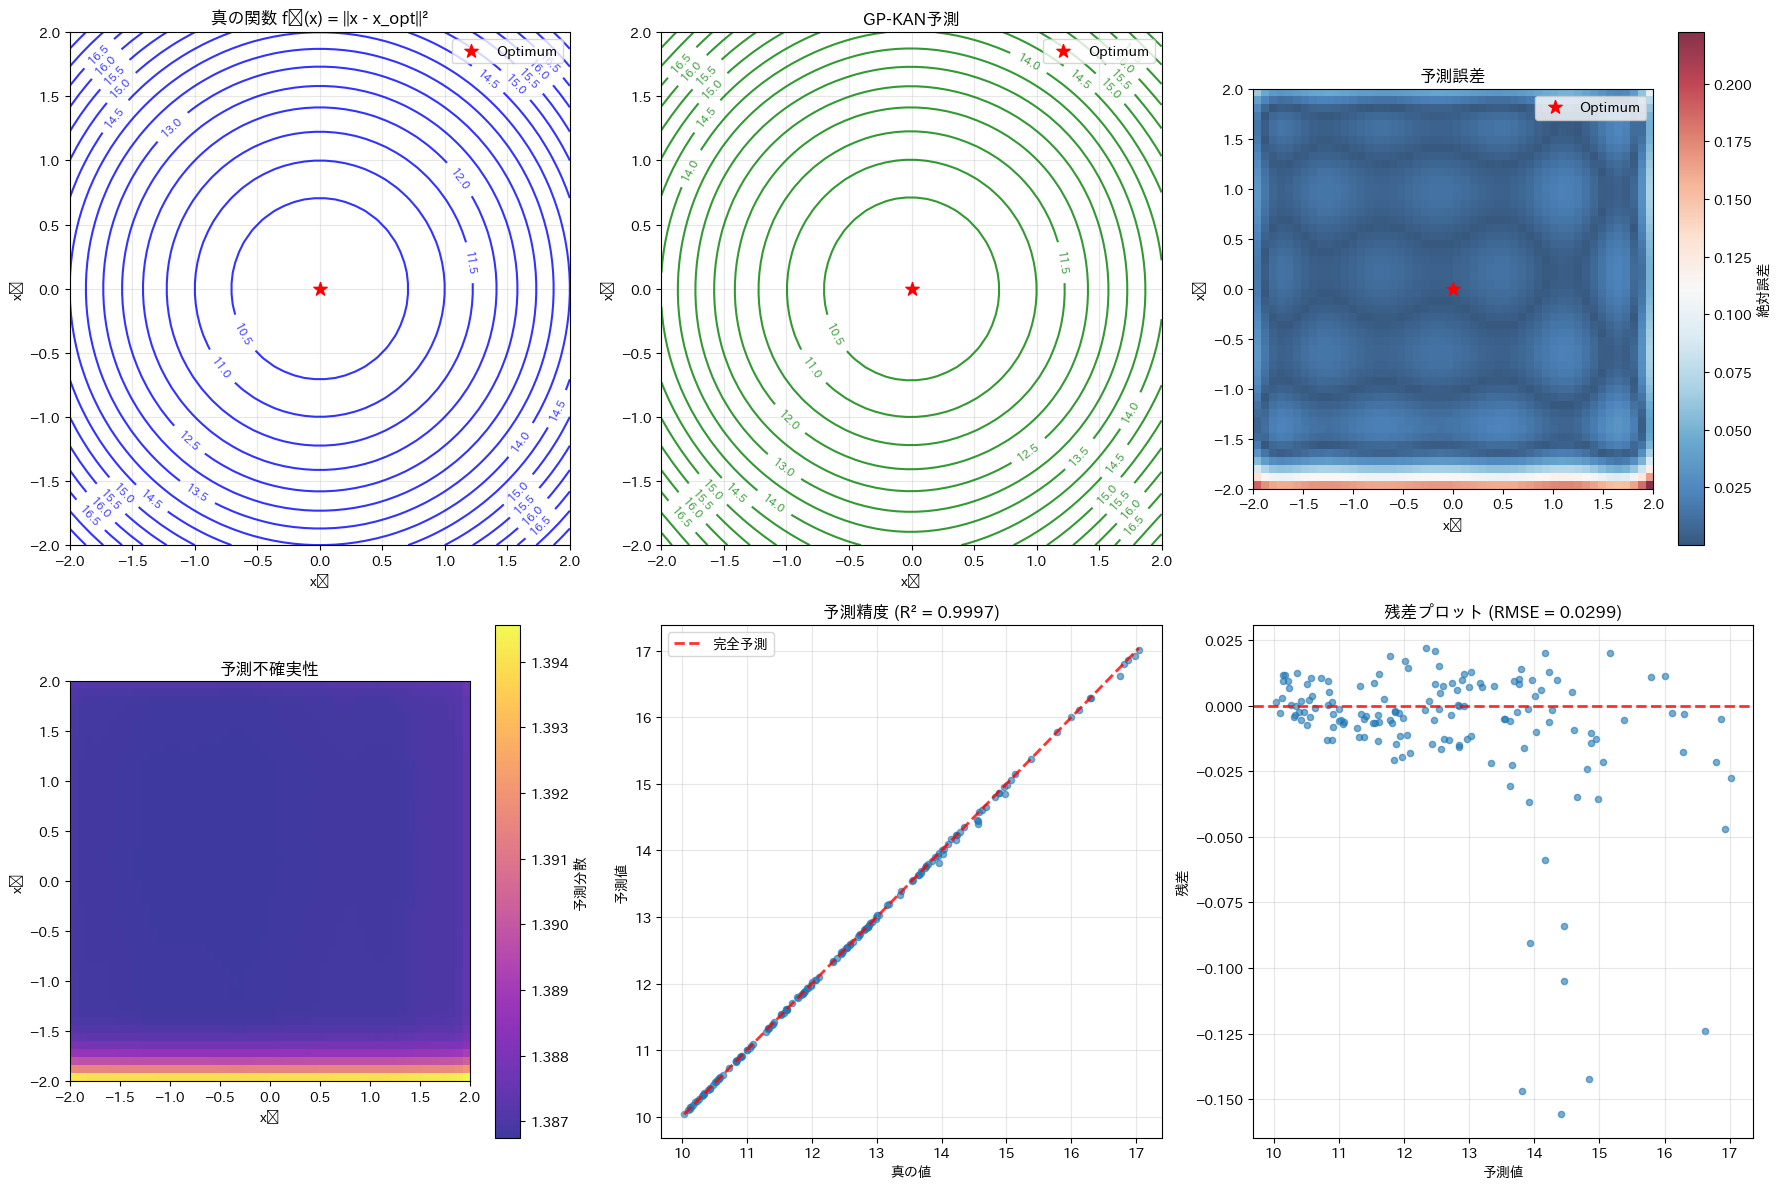


GP-KAN 近似性能サマリー
目標関数: f₁(x) = ||x - x_opt||² + f_opt
  最適解位置: x_opt = [0 0]
  最適値: f_opt = 10.0
学習データ数: 700
テストRMSE: 0.029868
テストR²: 0.999713
誘導点数: 16


In [13]:
japanize_matplotlib.japanize()
# ============================================================================
# 予測結果の詳細可視化（2D関数）
# ============================================================================

# 密なグリッドでの予測
grid_density = 50
x1_dense = np.linspace(input_range[0], input_range[1], grid_density)
x2_dense = np.linspace(input_range[0], input_range[1], grid_density)
X1_dense, X2_dense = np.meshgrid(x1_dense, x2_dense)
grid_dense = torch.FloatTensor(
    np.column_stack([X1_dense.ravel(), X2_dense.ravel()])
)

# バッチ処理での予測
with torch.no_grad():
    dense_means = []
    dense_vars = []
    
    dense_batch_size = 100
    for i in range(0, len(grid_dense), dense_batch_size):
        batch_grid = grid_dense[i:i + dense_batch_size]
        pred_mean, pred_var = gpkan_model.predict(batch_grid)
        dense_means.append(pred_mean)
        dense_vars.append(pred_var)
    
    dense_mean = torch.cat(dense_means, dim=0).reshape(grid_density, grid_density)
    dense_var = torch.cat(dense_vars, dim=0).reshape(grid_density, grid_density)

# 真の関数値
true_dense = target_function(grid_dense.numpy()).reshape(grid_density, grid_density)

# 6つのサブプロットで可視化
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. 真の関数（等高線）
contour1 = axes[0, 0].contour(
    X1_dense, X2_dense, true_dense, levels=15, colors='blue', alpha=0.8
)
axes[0, 0].clabel(contour1, inline=True, fontsize=8)
axes[0, 0].scatter(
    x_opt[0], x_opt[1], c='red', s=100, marker='*',
    label='Optimum', zorder=5
)
axes[0, 0].set_title('真の関数 f₁(x) = ||x - x_opt||²', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('x₁')
axes[0, 0].set_ylabel('x₂')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. GP-KAN予測（等高線）
contour2 = axes[0, 1].contour(
    X1_dense, X2_dense, dense_mean.numpy(), levels=15, colors='green', alpha=0.8
)
axes[0, 1].clabel(contour2, inline=True, fontsize=8)
axes[0, 1].scatter(
    x_opt[0], x_opt[1], c='red', s=100, marker='*',
    label='Optimum', zorder=5
)
axes[0, 1].set_title('GP-KAN予測', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('x₁')
axes[0, 1].set_ylabel('x₂')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. 予測誤差
error_dense = np.abs(dense_mean.numpy() - true_dense)
im1 = axes[0, 2].imshow(
    error_dense,
    extent=[input_range[0], input_range[1], input_range[0], input_range[1]],
    origin='lower', cmap='RdBu_r', alpha=0.8
)
axes[0, 2].scatter(
    x_opt[0], x_opt[1], c='red', s=100, marker='*',
    label='Optimum', zorder=5
)
plt.colorbar(im1, ax=axes[0, 2], label='絶対誤差')
axes[0, 2].set_title('予測誤差', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('x₁')
axes[0, 2].set_ylabel('x₂')
axes[0, 2].legend()

# 4. 予測不確実性（分散）
im2 = axes[1, 0].imshow(
    dense_var.numpy(),
    extent=[input_range[0], input_range[1], input_range[0], input_range[1]],
    origin='lower', cmap='plasma', alpha=0.8
)
plt.colorbar(im2, ax=axes[1, 0], label='予測分散')
axes[1, 0].set_title('予測不確実性', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('x₁')
axes[1, 0].set_ylabel('x₂')

# 5. 散布図: 真の値 vs 予測値
axes[1, 1].scatter(y_test.numpy(), test_mean.numpy(), alpha=0.6, s=20)
min_val = min(y_test.min().item(), test_mean.min().item())
max_val = max(y_test.max().item(), test_mean.max().item())
axes[1, 1].plot(
    [min_val, max_val], [min_val, max_val], 'r--',
    alpha=0.8, label='完全予測', linewidth=2
)
axes[1, 1].set_xlabel('真の値')
axes[1, 1].set_ylabel('予測値')
axes[1, 1].set_title(f'予測精度 (R² = {test_r2.item():.4f})',
                      fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. 残差プロット
residuals = (test_mean - y_test.squeeze()).numpy()
axes[1, 2].scatter(test_mean.numpy(), residuals, alpha=0.6, s=20)
axes[1, 2].axhline(y=0, color='r', linestyle='--', alpha=0.8, linewidth=2)
axes[1, 2].set_xlabel('予測値')
axes[1, 2].set_ylabel('残差')
axes[1, 2].set_title(f'残差プロット (RMSE = {test_rmse.item():.4f})',
                      fontsize=12, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# サマリー表示
print("\n" + "=" * 60)
print("GP-KAN 近似性能サマリー")
print("=" * 60)
print(f"目標関数: f₁(x) = ||x - x_opt||² + f_opt")
print(f"  最適解位置: x_opt = {x_opt}")
print(f"  最適値: f_opt = {f_opt}")
print(f"学習データ数: {len(train_dataset)}")
print(f"テストRMSE: {test_rmse.item():.6f}")
print(f"テストR²: {test_r2.item():.6f}")
print(f"誘導点数: {NUM_INDUCING}")
print("=" * 60)

### 5.1 GP活性化関数の可視化

各レイヤーのGPエッジがどのような非線形変換を学習したかを可視化します。


=== GP活性化関数の可視化 ===


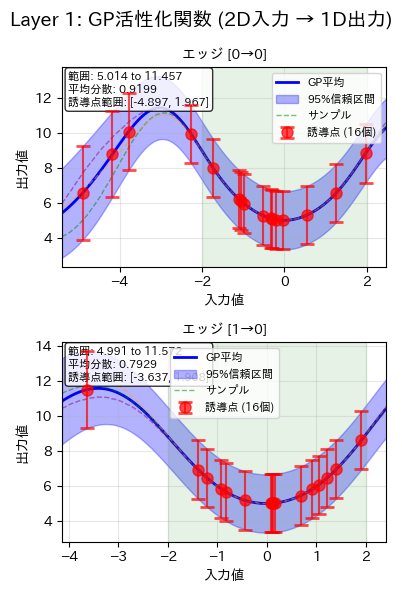


Layer 1 統計
入力次元: 2
出力次元: 1
総GPエッジ数: 2
エッジあたり誘導点数: 16
レイヤー総誘導点数: 32



In [14]:
japanize_matplotlib.japanize()
# ============================================================================
# GP活性化関数の可視化
# ============================================================================

def visualize_gp_activation_functions(
    model: GPKAN,
    input_range: tuple = (-2.0, 2.0),
    num_points: int = 100
):
    """
    各レイヤーのGPエッジの活性化関数を可視化
    
    Args:
        model: 学習済みGP-KANモデル
        input_range: 可視化する入力範囲
        num_points: プロット点数
    """
    model.eval_mode()
    
    # 各レイヤーを可視化
    for layer_idx, layer in enumerate(model.layers):
        input_size = layer.input_size
        output_size = layer.output_size
        
        # サブプロットグリッドの作成
        fig, axes = plt.subplots(
            input_size, output_size,
            figsize=(4 * output_size, 3 * input_size),
            squeeze=False
        )
        
        fig.suptitle(
            f'Layer {layer_idx + 1}: GP活性化関数 ' +
            f'({input_size}D入力 → {output_size}D出力)',
            fontsize=14, fontweight='bold'
        )
        
        # 各GPエッジを可視化
        for i in range(input_size):
            for j in range(output_size):
                ax = axes[i, j]
                gp_edge = layer.gp_edges[i][j]
                likelihood = layer.likelihoods[i][j]
                
                with torch.no_grad():
                    # 誘導点の範囲を取得
                    inducing_points = gp_edge.get_inducing_points()
                    inducing_min = inducing_points.min().item()
                    inducing_max = inducing_points.max().item()
                    
                    # 可視化範囲を誘導点の範囲を含むように拡張
                    plot_min = min(input_range[0], inducing_min - 0.5)
                    plot_max = max(input_range[1], inducing_max + 0.5)
                    
                    # 拡張された範囲でテスト入力を作成
                    x_test = torch.linspace(plot_min, plot_max, num_points).reshape(-1, 1)
                    
                    # GP予測
                    gp_output = gp_edge(x_test)
                    pred_dist = likelihood(gp_output)
                    
                    mean = pred_dist.mean
                    variance = pred_dist.variance
                    std = torch.sqrt(variance)
                    
                    # 誘導点での予測
                    inducing_output = gp_edge(inducing_points)
                    inducing_pred = likelihood(inducing_output)
                    inducing_mean = inducing_pred.mean
                    inducing_std = torch.sqrt(inducing_pred.variance)
                    
                    # サンプル関数（3つ）
                    sample_functions = [gp_output.sample() for _ in range(3)]
                
                # プロット
                x_np = x_test.squeeze().detach().numpy()
                mean_np = mean.detach().numpy()
                std_np = std.detach().numpy()
                
                # GP平均と信頼区間
                ax.plot(x_np, mean_np, 'b-', linewidth=2, label='GP平均')
                ax.fill_between(
                    x_np, mean_np - 2*std_np, mean_np + 2*std_np,
                    alpha=0.3, color='blue', label='95%信頼区間'
                )
                
                # 誘導点と誘導点での信頼区間
                inducing_x = inducing_points.squeeze().detach().numpy()
                inducing_y = inducing_mean.detach().numpy()
                inducing_std_np = inducing_std.detach().numpy()
                
                # 誘導点での信頼区間（エラーバー）
                ax.errorbar(
                    inducing_x, inducing_y, 
                    yerr=2*inducing_std_np,
                    fmt='o', color='red', markersize=8,
                    ecolor='red', capsize=5, capthick=2,
                    alpha=0.7, zorder=5,
                    label=f'誘導点 ({len(inducing_x)}個)'
                )
                
                # サンプル関数
                colors = ['green', 'orange', 'purple']
                for idx, sample in enumerate(sample_functions):
                    sample_np = sample.detach().numpy()
                    ax.plot(
                        x_np, sample_np, '--', alpha=0.5,
                        linewidth=1, color=colors[idx],
                        label='サンプル' if idx == 0 else None
                    )
                
                # 装飾
                ax.set_title(
                    f'エッジ [{i}→{j}]',
                    fontsize=10, fontweight='bold'
                )
                ax.set_xlabel('入力値')
                ax.set_ylabel('出力値')
                ax.set_xlim(plot_min, plot_max)  # X軸範囲を拡張
                ax.grid(True, alpha=0.3)
                ax.legend(fontsize=8, loc='best')
                
                # データ範囲と誘導点範囲の可視化
                ax.axvspan(input_range[0], input_range[1], alpha=0.1, color='green', label='データ範囲')
                
                # 統計情報
                mean_range = f"{mean_np.min():.3f} to {mean_np.max():.3f}"
                var_mean = f"{variance.mean().item():.4f}"
                inducing_range_str = f"[{inducing_min:.3f}, {inducing_max:.3f}]"
                ax.text(
                    0.02, 0.98, 
                    f'範囲: {mean_range}\n平均分散: {var_mean}\n誘導点範囲: {inducing_range_str}',
                    transform=ax.transAxes, fontsize=8,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
                )
        
        plt.tight_layout()
        plt.show()
        
        # レイヤー統計
        total_edges = input_size * output_size
        print(f"\n{'='*60}")
        print(f"Layer {layer_idx + 1} 統計")
        print(f"{'='*60}")
        print(f"入力次元: {input_size}")
        print(f"出力次元: {output_size}")
        print(f"総GPエッジ数: {total_edges}")
        print(f"エッジあたり誘導点数: {len(gp_edge.get_inducing_points())}")
        print(f"レイヤー総誘導点数: {total_edges * len(gp_edge.get_inducing_points())}")
        print(f"{'='*60}\n")

# GP活性化関数の可視化実行
print("\n=== GP活性化関数の可視化 ===")
visualize_gp_activation_functions(
    gpkan_model,
    input_range=(-2.0, 2.0),
    num_points=100
)

In [15]:
# ============================================================================
# GPエッジの特性分析
# ============================================================================

def analyze_gp_edge_properties(model: GPKAN):
    """
    各GPエッジの学習されたカーネルパラメータを分析
    
    Args:
        model: 学習済みGP-KANモデル
    """
    model.eval_mode()
    
    print("\n" + "=" * 60)
    print("GP-KAN エッジ分析")
    print("=" * 60)
    
    for layer_idx, layer in enumerate(model.layers):
        print(f"\n--- Layer {layer_idx + 1} ---")
        print(f"構造: {layer.input_size}入力 × {layer.output_size}出力")
        
        edge_info = []
        
        # 各エッジの特性を収集
        for i in range(layer.input_size):
            for j in range(layer.output_size):
                gp_edge = layer.gp_edges[i][j]
                likelihood = layer.likelihoods[i][j]
                
                inducing_points = gp_edge.get_inducing_points()
                
                with torch.no_grad():
                    # カーネルパラメータ
                    if hasattr(gp_edge.covar_module, 'outputscale'):
                        outputscale = gp_edge.covar_module.outputscale.item()
                    else:
                        outputscale = 1.0
                    
                    if hasattr(gp_edge.covar_module.base_kernel, 'lengthscale'):
                        lengthscale = gp_edge.covar_module.base_kernel.lengthscale.item()
                    else:
                        lengthscale = 1.0
                    
                    # ノイズパラメータ
                    noise_var = likelihood.noise.item()
                    
                    # 誘導点の範囲
                    inducing_span = (inducing_points.max() - inducing_points.min()).item()
                    
                    edge_info.append({
                        'edge': f'[{i}→{j}]',
                        'outputscale': outputscale,
                        'lengthscale': lengthscale,
                        'noise_var': noise_var,
                        'inducing_span': inducing_span,
                        'num_inducing': len(inducing_points)
                    })
        
        # 統計サマリー
        if edge_info:
            import pandas as pd
            df = pd.DataFrame(edge_info)
            
            print(f"\nエッジ数: {len(edge_info)}")
            print("\nカーネルパラメータ統計:")
            print(f"  Outputscale - 平均: {df['outputscale'].mean():.4f}, " +
                  f"標準偏差: {df['outputscale'].std():.4f}")
            print(f"  Lengthscale - 平均: {df['lengthscale'].mean():.4f}, " +
                  f"標準偏差: {df['lengthscale'].std():.4f}")
            print(f"  Noise Var   - 平均: {df['noise_var'].mean():.4f}, " +
                  f"標準偏差: {df['noise_var'].std():.4f}")
            print(f"  誘導点範囲  - 平均: {df['inducing_span'].mean():.4f}, " +
                  f"標準偏差: {df['inducing_span'].std():.4f}")
            
            print("\n詳細なエッジ情報:")
            for info in edge_info:
                print(f"  {info['edge']}: " +
                      f"OutputScale={info['outputscale']:.3f}, " +
                      f"Lengthscale={info['lengthscale']:.3f}, " +
                      f"Noise={info['noise_var']:.4f}, " +
                      f"IndSpan={info['inducing_span']:.3f}")
    
    print("\n" + "=" * 60)

# エッジ特性分析の実行
analyze_gp_edge_properties(gpkan_model)


GP-KAN エッジ分析

--- Layer 1 ---
構造: 2入力 × 1出力

エッジ数: 2

カーネルパラメータ統計:
  Outputscale - 平均: 0.8205, 標準偏差: 0.3485
  Lengthscale - 平均: 1.4750, 標準偏差: 0.4118
  Noise Var   - 平均: 0.6932, 標準偏差: 0.0000
  誘導点範囲  - 平均: 6.2044, 標準偏差: 0.9329

詳細なエッジ情報:
  [0→0]: OutputScale=0.574, Lengthscale=1.184, Noise=0.6932, IndSpan=6.864
  [1→0]: OutputScale=1.067, Lengthscale=1.766, Noise=0.6932, IndSpan=5.545


エッジ数: 2

カーネルパラメータ統計:
  Outputscale - 平均: 0.8205, 標準偏差: 0.3485
  Lengthscale - 平均: 1.4750, 標準偏差: 0.4118
  Noise Var   - 平均: 0.6932, 標準偏差: 0.0000
  誘導点範囲  - 平均: 6.2044, 標準偏差: 0.9329

詳細なエッジ情報:
  [0→0]: OutputScale=0.574, Lengthscale=1.184, Noise=0.6932, IndSpan=6.864
  [1→0]: OutputScale=1.067, Lengthscale=1.766, Noise=0.6932, IndSpan=5.545




Layer 1 エッジ応答比較


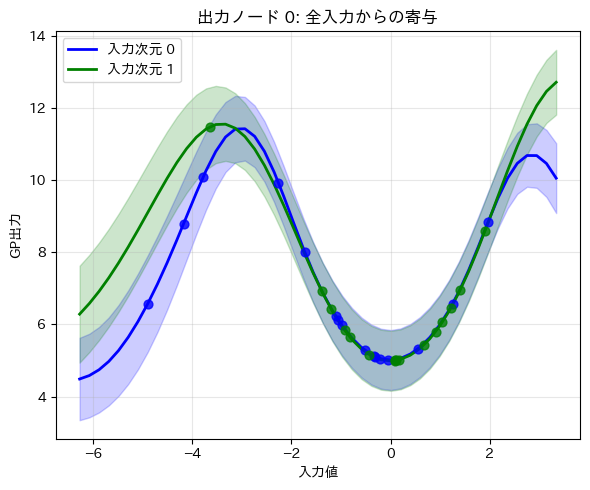


Layer 1 エッジ応答統計:
  出力ノード 0:
    入力次元 0: 原点での応答 = 5.0135, 分散 = 0.0001
    入力次元 1: 原点での応答 = 4.9906, 分散 = 0.0001


In [17]:
japanize_matplotlib.japanize()
# ============================================================================
# レイヤーごとのエッジ応答比較
# ============================================================================

def compare_edge_responses(
    model: GPKAN,
    layer_idx: int = 0,
    input_range: tuple = (-2.0, 2.0)
):
    """
    特定のレイヤーにおける全エッジの応答を比較
    
    Args:
        model: 学習済みGP-KANモデル
        layer_idx: 分析するレイヤーのインデックス
        input_range: テスト入力の範囲
    """
    if layer_idx >= len(model.layers):
        print(f"エラー: Layer index {layer_idx} は範囲外です")
        return
    
    model.eval_mode()
    layer = model.layers[layer_idx]
    
    # テスト入力
    test_input = torch.linspace(input_range[0], input_range[1], 50).reshape(-1, 1)
    
    print(f"\n{'='*60}")
    print(f"Layer {layer_idx + 1} エッジ応答比較")
    print(f"{'='*60}")
    
    # 各出力ノードに対して可視化
    fig, axes = plt.subplots(
        1, layer.output_size,
        figsize=(6 * layer.output_size, 5)
    )
    if layer.output_size == 1:
        axes = [axes]
    
    for j in range(layer.output_size):
        ax = axes[j]
        
        # 出力ノード j への全入力からの寄与を表示
        for i in range(layer.input_size):
            gp_edge = layer.gp_edges[i][j]
            likelihood = layer.likelihoods[i][j]
            
            with torch.no_grad():
                # GP予測
                gp_output = gp_edge(test_input)
                pred_dist = likelihood(gp_output)
                mean = pred_dist.mean
                std = torch.sqrt(pred_dist.variance)
                
                # 誘導点
                inducing_points = gp_edge.get_inducing_points()
                inducing_output = gp_edge(inducing_points)
                inducing_pred = likelihood(inducing_output)
                inducing_mean = inducing_pred.mean
            
            # プロット
            x_np = test_input.squeeze().detach().numpy()
            mean_np = mean.detach().numpy()
            std_np = std.detach().numpy()
            
            color = ['blue', 'green', 'red', 'orange', 'purple'][i % 5]
            
            # GP関数
            ax.plot(x_np, mean_np, color=color, linewidth=2,
                   label=f'入力次元 {i}')
            ax.fill_between(
                x_np, mean_np - std_np, mean_np + std_np,
                alpha=0.2, color=color
            )
            
            # 誘導点
            inducing_x = inducing_points.squeeze().detach().numpy()
            inducing_y = inducing_mean.detach().numpy()
            ax.scatter(
                inducing_x, inducing_y, c=color,
                s=40, marker='o', alpha=0.8, zorder=5
            )
        
        ax.set_title(f'出力ノード {j}: 全入力からの寄与',
                    fontsize=12, fontweight='bold')
        ax.set_xlabel('入力値')
        ax.set_ylabel('GP出力')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 数値的な比較
    print(f"\nLayer {layer_idx + 1} エッジ応答統計:")
    for j in range(layer.output_size):
        print(f"  出力ノード {j}:")
        for i in range(layer.input_size):
            gp_edge = layer.gp_edges[i][j]
            
            with torch.no_grad():
                # 原点での応答を計算
                test_point = torch.tensor([[0.0]])
                gp_output = gp_edge(test_point)
                response_at_origin = gp_output.mean.item()
                gp_var = gp_output.variance.item()
                
                print(f"    入力次元 {i}: 原点での応答 = {response_at_origin:.4f}, " +
                      f"分散 = {gp_var:.4f}")
    
    print("=" * 60)

# 第1層のエッジ応答比較
# 誘導点の範囲を考慮したinput_rangeを設定
# モデルの誘導点の範囲を確認して、それを含むように設定
layer = gpkan_model.layers[0]
all_inducing_points = []
for i in range(layer.input_size):
    for j in range(layer.output_size):
        inducing_pts = layer.gp_edges[i][j].get_inducing_points().detach().numpy().flatten()
        all_inducing_points.extend(inducing_pts)

if len(all_inducing_points) > 0:
    inducing_min = float(np.min(all_inducing_points))
    inducing_max = float(np.max(all_inducing_points))
    # 誘導点の範囲に余裕を持たせる
    margin = (inducing_max - inducing_min) * 0.2
    input_range = (inducing_min - margin, inducing_max + margin)
else:
    input_range = (-2.0, 2.0)

compare_edge_responses(gpkan_model, layer_idx=0, input_range=input_range)